In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import fitsio
import glob
import scipy

import numpy as np
import healpy as hp
import xlens
import treecorr
import astropy.io.ascii as pyascii
import numpy.lib.recfunctions as rfn
from lsst.geom import degrees

from lsst.daf.butler import Butler
from lsst.skymap.ringsSkyMap import RingsSkyMap, RingsSkyMapConfig

import lsst.afw.image as afwImage
from astropy.visualization import ZScaleInterval
from xlens.process_pipe.anacal_detect import (
    AnacalDetectPipe, AnacalDetectPipeConfig
)
test_dir = f"/gpfs02/work/xiangchong.li/work/hsc_data/s23b/deepCoadd_anacal_v2/tests_multiband_weight/imag25.0_emax0.40/"

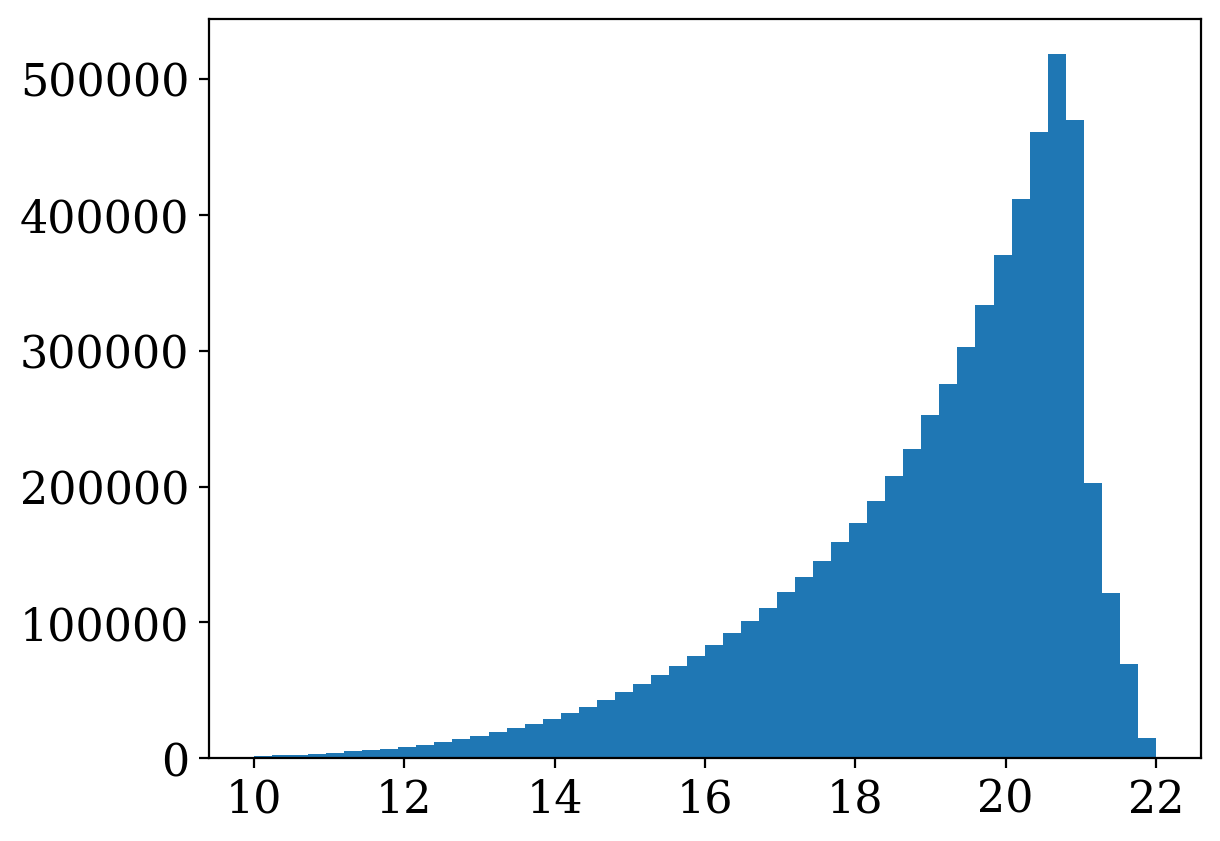

In [2]:
stars = fitsio.read("/gpfs02/work/xiangchong.li/work/hsc_data/s23b/gaia/stars.fits")
_ = plt.hist(stars["g_mag"], bins=50, range=(10, 22))

In [3]:
# Create x, y, yerr for all 6 plots
x_data = []
y_data = []
y_errs = []

def compute_xy(data_subset):
    arr = np.average(data_subset, axis=0)
    x  = arr[0]
    y1 = arr[1] / arr[3]
    y2 = arr[2] / arr[3]
    return x, y1, y2

for ff in ["gaia_bright", "gaia_median", "gaia_faint"]:
    data = fitsio.read(f"{test_dir}/NG_{ff}.fits")
    # get the "nominal" values
    x, y1, y2 = compute_xy(data)

    # ---- bootstrap parameters ----
    nboot = 2000                      # number of bootstrap samples
    nreal = data.shape[0]             # how many realizations you have
    # pre-allocate arrays to hold each trial
    y1_boot = np.empty((nboot, y1.size))
    y2_boot = np.empty((nboot, y2.size))

    # ---- run the bootstrap ----
    for i in range(nboot):
        # sample `nreal` indices with replacement
        idx = np.random.choice(nreal, size=nreal, replace=True)
        # compute ratios on that resampled set
        _, y1_i, y2_i = compute_xy(data[idx])
        y1_boot[i] = y1_i
        y2_boot[i] = y2_i

    # ---- compute the 1-sigma errors ----
    y1_err = np.std(y1_boot, axis=0)
    y2_err = np.std(y2_boot, axis=0)

    x_data.extend([x, x])
    y_data.extend([y1, y2])
    y_errs.extend([y1_err, y2_err])

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_558/977925831.py:9: RuntimeWarning: invalid value encountered in divide
  y1 = arr[1] / arr[3]
/gpfs02/work/xiangchong.li/work/tmp/ipykernel_558/977925831.py:10: RuntimeWarning: invalid value encountered in divide
  y2 = arr[2] / arr[3]


tangential i=0: chi2=15.46, df=10, p=0.1161
tangential i=2: chi2=21.61, df=13, p=0.0617
tangential i=4: chi2=24.24, df=15, p=0.0611
cross i=1: chi2=13.43, df=10, p=0.2006
cross i=3: chi2=7.51, df=13, p=0.8738
cross i=5: chi2=11.04, df=15, p=0.7494


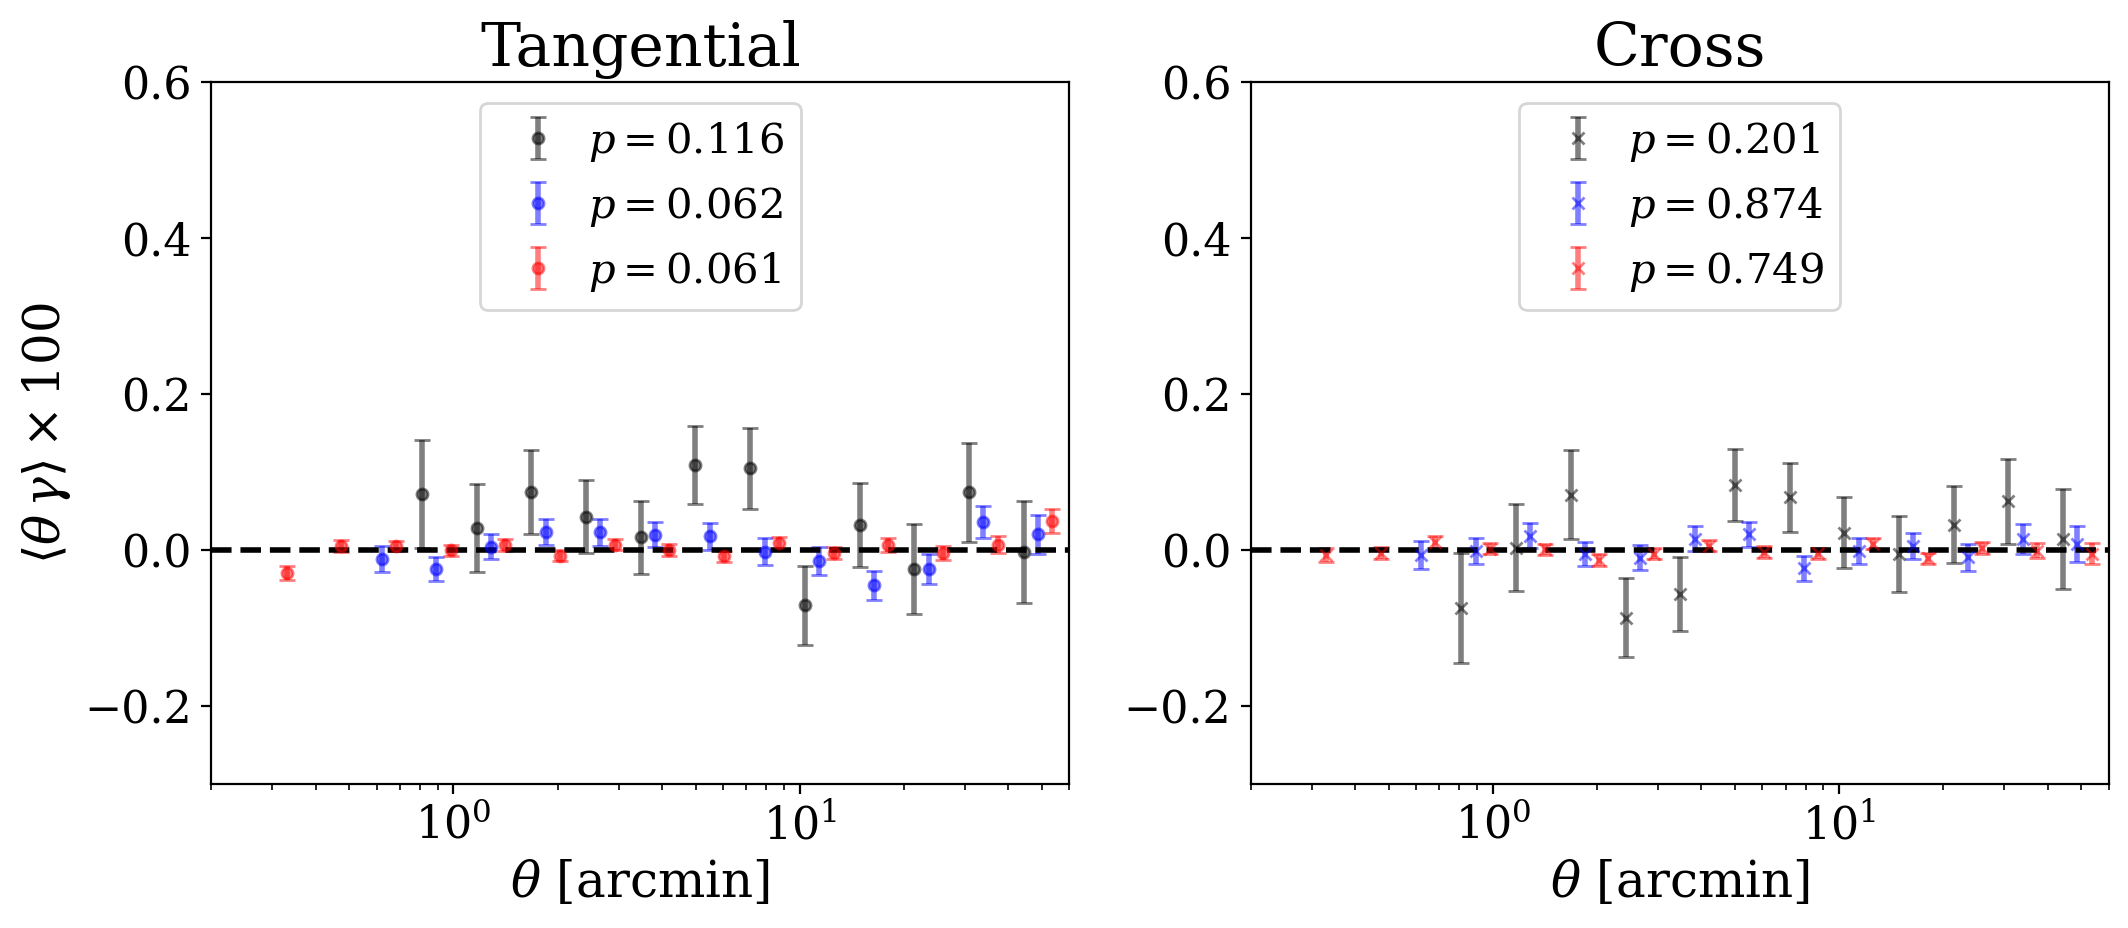

In [4]:
multiply = 100
plt.close()


def pvalue_chi2(y, yerr):
    """Compute chi2 = sum((y / yerr)**2) using diagonal errors."""
    chi2 = np.sum((y / yerr) ** 2)
    df = len(y)
    p = scipy.stats.chi2.sf(chi2, df)
    return p, chi2, df


colors = ["black", "blue", "red"]
rr = [1.0 / 1.10, 1.00, 1.10]

_, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
iend = -5
for i in [0, 2, 4]:
    if i == 0:
        istart = 5
    elif i == 2:
        istart = 2
    else:
        istart = 0
    y_sel = y_data[i][istart:iend]
    yerr_sel = y_errs[i][istart:iend]
    pv, chi2, df = pvalue_chi2(y_sel, yerr_sel)
    ax.errorbar(
        x_data[i] * rr[i//2],
        y_data[i] * x_data[i] * multiply,
        y_errs[i] * x_data[i] * multiply,
        fmt='o', ms=4, capsize=3, linestyle='', alpha=0.5,
        color=colors[i // 2],
        label=r"$p=%.3f$" % (pv),
    )
    print(f"tangential i={i}: chi2={chi2:.2f}, df={df}, p={pv:.4f}")

ax.set_xscale('log')
ax.legend(fontsize=15, loc="upper center", handletextpad=0.2)
ax.axhline(0.0, ls='--', color='black')
ax.set_title("Tangential")
ax.set_xlabel(r"$\theta\ \mathrm{[arcmin]}$")
ax.set_ylabel(r"$\langle \theta\,\gamma \rangle \times 100$")
ax.set_xlim(0.2, 60)
ax.set_ylim(-0.3, 0.6)

ax = axes[1]
for i in [1, 3, 5]:
    if i == 1:
        istart = 5
    elif i == 3:
        istart = 2
    else:
        istart = 0
    y_sel = y_data[i][istart:iend]
    yerr_sel = y_errs[i][istart:iend]
    pv, chi2, df = pvalue_chi2(y_sel, yerr_sel)
    ax.errorbar(
        x_data[i] * rr[i//2],
        y_data[i] * x_data[i] * multiply,
        y_errs[i] * x_data[i] * multiply,
        fmt='x', ms=4, capsize=3, linestyle='', alpha=0.5,
        color=colors[i // 2],
        label=r"$p =%.3f$" % (pv),
    )
    print(f"cross i={i}: chi2={chi2:.2f}, df={df}, p={pv:.4f}")

ax.set_xscale('log')
ax.legend(fontsize=15, loc="upper center", handletextpad=0.2)
ax.set_xlim(0.2, 60)
ax.set_ylim(-0.3, 0.6)
ax.axhline(0.0, ls='--', color='black')
ax.set_title("Cross")
ax.set_xlabel(r"$\theta\ \mathrm{[arcmin]}$")

plt.tight_layout()
plt.show()